In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
    
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


---
## **실습 5 - 종합 분석 리포트**
`한 엔진을 추세, 변동성, 상관까지 분석하고 리포트로 정리`

In [3]:
df_5 = pd.read_csv("..\\Data\\21_cmapss_fd001_sample.csv")
print("shape:", df_5.shape)

sensors = ["s_2", "s_3", "s_4", "s_7", "s_11"]

e2_5 = df_5[df_5["unit_nr"] == 2].reset_index(drop=True)
print("2번 엔진:", e2_5.shape, "| 회차", e2_5["time_cycles"].min(), "~", e2_5["time_cycles"].max())
print(e2_5[["time_cycles"] + sensors].head(3))

shape: (1031, 10)
2번 엔진: (287, 10) | 회차 1 ~ 287
   time_cycles     s_2      s_3      s_4     s_7    s_11
0            1  640.95  1585.27  1399.71  554.13  47.216
1            2  640.83  1585.76  1400.55  554.23  47.013
2            3  640.17  1585.38  1398.30  553.76  47.043


변동성 기준선: 1.3247 | 기준 초과 회차: 47 개
min ~ max로 잡으면: 171 ~ 287 (너무 넓음)

[연속 초과 구간 목록]
  171 ~ 173 회차 (3개)
  201 ~ 212 회차 (12개)
  217 ~ 217 회차 (1개)
  237 ~ 239 회차 (3개)
  251 ~ 254 회차 (4개)
  261 ~ 263 회차 (3개)
  267 ~ 287 회차 (21개)

가장 긴 구간을 의심 구간으로 선정: 267 ~ 287 회차 ( 21 개 )


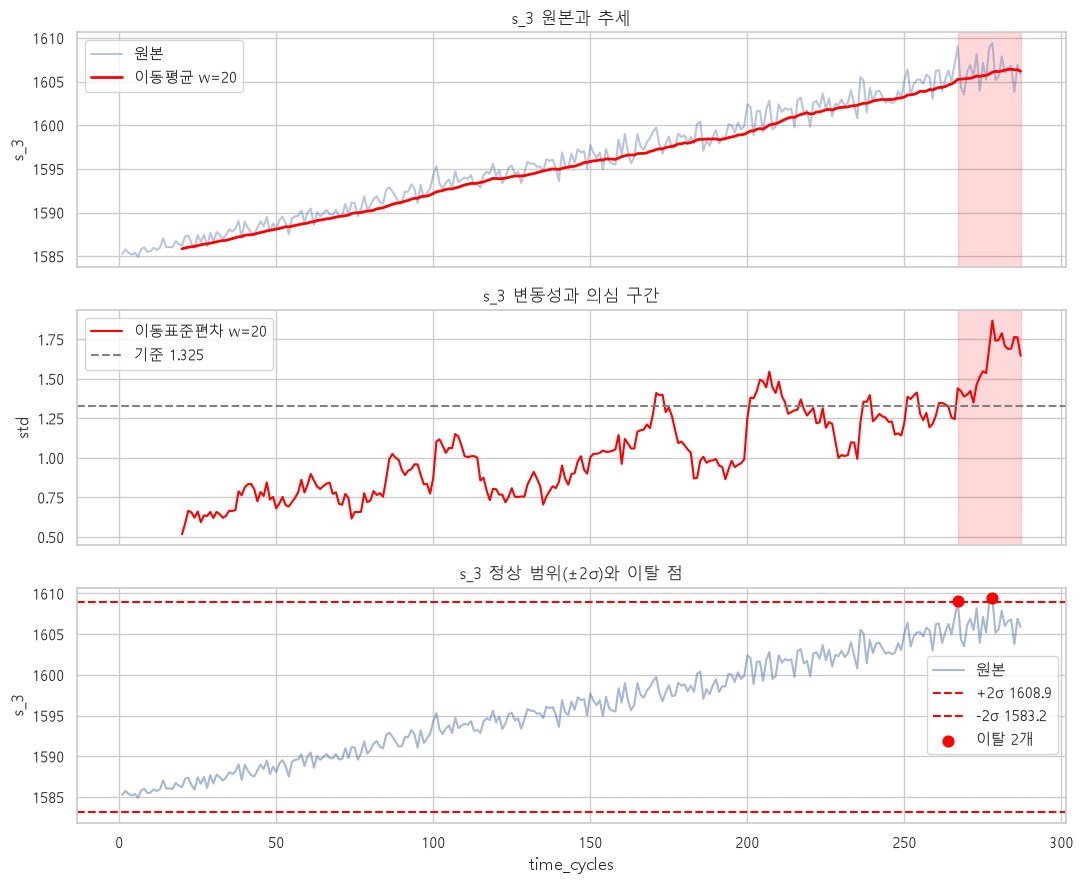

In [4]:
# 추세와 변동성 그래프를 그리고 의심 구간을 표시
ma_5 = e2_5["s_3"].rolling(window=20).mean()    # 추세 - 이동평균
sd_5 = e2_5["s_3"].rolling(window=20).std()     # 변동성 - 이동표준편차

# 의심 구간을 눈대중이 아니라 숫자로 정해서 잡는다
# 이동표준편차가 (평균 + 1표준편차)를 넘는 회차를 의심 후보로 본다
기준_5 = sd_5.mean() + sd_5.std()
초과_5 = (sd_5 > 기준_5).fillna(False)
print("변동성 기준선:", round(기준_5, 4), "| 기준 초과 회차:", 초과_5.sum(), "개")

# 초과 회차의 min ~ max로 잡으면 안 된다
# 초과 지점이 중간중간 흩어져 있어서 사이의 정상 구간까지 통째로 칠해진다
print("min ~ max로 잡으면:", e2_5.loc[초과_5, "time_cycles"].min(),
      "~", e2_5.loc[초과_5, "time_cycles"].max(), "(너무 넓음)")

# 연속으로 초과한 덩어리들을 찾아서 그중 가장 긴 것만 의심 구간으로 쓴다
# 값이 바뀔 때마다 번호가 올라가는 방식으로 덩어리에 번호를 매긴다
덩어리_5 = (초과_5 != 초과_5.shift()).cumsum()

구간들_5 = []
for g_5 in 덩어리_5[초과_5].unique():
    mask_5 = 초과_5 & (덩어리_5 == g_5)
    구간들_5.append((e2_5.loc[mask_5, "time_cycles"].min(),
                   e2_5.loc[mask_5, "time_cycles"].max(),
                   mask_5.sum()))

print()
print("[연속 초과 구간 목록]")
for a_5, b_5, n_5 in 구간들_5:
    print(f"  {a_5:3} ~ {b_5:3} 회차 ({n_5}개)")

시작_5, 끝_5, 길이_5 = max(구간들_5, key=lambda r: r[2])
print()
print("가장 긴 구간을 의심 구간으로 선정:", 시작_5, "~", 끝_5, "회차 (", 길이_5, "개 )")

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# 위칸 - 원본과 추세
axes[0].plot(e2_5["time_cycles"], e2_5["s_3"], alpha=0.4, label="원본")
axes[0].plot(e2_5["time_cycles"], ma_5, linewidth=2, color="red", label="이동평균 w=20")
axes[0].axvspan(시작_5, 끝_5, color="red", alpha=0.15)
axes[0].set_title("s_3 원본과 추세")
axes[0].set_ylabel("s_3")
axes[0].legend()

# 가운데칸 - 변동성
axes[1].plot(e2_5["time_cycles"], sd_5, color="red", label="이동표준편차 w=20")
axes[1].axhline(기준_5, color="gray", linestyle="--", label=f"기준 {기준_5:.3f}")
axes[1].axvspan(시작_5, 끝_5, color="red", alpha=0.15)
axes[1].set_title("s_3 변동성과 의심 구간")
axes[1].set_ylabel("std")
axes[1].legend()

# 아래칸 - 정상 범위 밴드를 벗어난 점
m_5, sd_all_5 = e2_5["s_3"].mean(), e2_5["s_3"].std()
lower_5, upper_5 = m_5 - 2 * sd_all_5, m_5 + 2 * sd_all_5
밖_5 = (e2_5["s_3"] > upper_5) | (e2_5["s_3"] < lower_5)

axes[2].plot(e2_5["time_cycles"], e2_5["s_3"], alpha=0.5, label="원본")
axes[2].axhline(upper_5, color="red", linestyle="--", label=f"+2σ {upper_5:.1f}")
axes[2].axhline(lower_5, color="red", linestyle="--", label=f"-2σ {lower_5:.1f}")
axes[2].scatter(e2_5.loc[밖_5, "time_cycles"], e2_5.loc[밖_5, "s_3"],
                color="red", s=60, zorder=5, label=f"이탈 {밖_5.sum()}개")
axes[2].set_title("s_3 정상 범위(±2σ)와 이탈 점")
axes[2].set_xlabel("time_cycles")
axes[2].set_ylabel("s_3")
axes[2].legend()

plt.tight_layout()
plt.show()

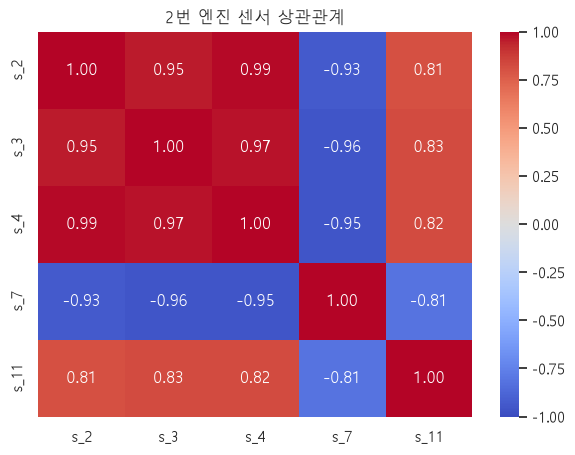

[|r| >= 0.9 인 센서 쌍]
  s_2-s_3    : +0.95
  s_2-s_4    : +0.99
  s_2-s_7    : -0.93
  s_3-s_4    : +0.97
  s_3-s_7    : -0.96
  s_4-s_7    : -0.95

양의 묶음: ['s_2-s_3', 's_2-s_4', 's_3-s_4']
음의 묶음: ['s_2-s_7', 's_3-s_7', 's_4-s_7']


In [5]:
# 상관 heatmap으로 센서 관계를 확인
corr_5 = e2_5[sensors].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_5, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("2번 엔진 센서 상관관계")
plt.show()

# 대각선을 빼고 절댓값 0.9 이상인 쌍만 골라내기
# 안쪽 루프를 j = i + 1로 시작해야 같은 쌍이 두 번 안 나온다
print("[|r| >= 0.9 인 센서 쌍]")
양_5, 음_5 = [], []
for i in range(len(sensors)):
    for j in range(i + 1, len(sensors)):
        c_5 = corr_5.iloc[i, j]
        if abs(c_5) >= 0.9:
            쌍_5 = f"{sensors[i]}-{sensors[j]}"
            print(f"  {쌍_5:10} : {c_5:+.2f}")
            (양_5 if c_5 > 0 else 음_5).append(쌍_5)

print()
print("양의 묶음:", 양_5)
print("음의 묶음:", 음_5)

In [6]:
# 사실과 해석을 구분한 짧은 리포트 출력
# 리포트에 들어갈 숫자는 전부 위에서 계산한 변수를 쓴다 (손으로 적으면 코드 고칠 때 어긋난다)
전반_5 = sd_5.iloc[: len(sd_5) // 2].mean()
후반_5 = sd_5.iloc[len(sd_5) // 2 :].mean()
r_5 = e2_5["time_cycles"].corr(e2_5["s_3"])
가장강한_5 = max(양_5 + 음_5, key=lambda p: abs(corr_5.loc[p.split("-")[0], p.split("-")[1]]))

print("=" * 62)
print("2번 엔진 s_3 센서 종합 분석 리포트")
print("=" * 62)
print("[사실] 관측 구간      : 1 ~ 287 회차 (총 {}개)".format(len(e2_5)))
print("[사실] 추세          : MA20 기준 {:.2f} -> {:.2f} (회차 상관 r={:+.3f})".format(
    ma_5.dropna().iloc[0], ma_5.dropna().iloc[-1], r_5))
print("[사실] 변동성        : 전반 {:.4f} -> 후반 {:.4f} ({:+.1f}%)".format(
    전반_5, 후반_5, (후반_5 / 전반_5 - 1) * 100))
print("[사실] 의심 구간     : {} ~ {} 회차 ({}개 연속, 이동표준편차 {:.3f} 초과)".format(
    시작_5, 끝_5, 길이_5, 기준_5))
print("[사실] 정상 범위     : {:.2f} ~ {:.2f}, 이탈 {}개".format(lower_5, upper_5, 밖_5.sum()))
print("[사실] 최강 상관 쌍  : {} ({:+.2f})".format(
    가장강한_5, corr_5.loc[가장강한_5.split("-")[0], 가장강한_5.split("-")[1]]))
print("-" * 62)
print("[해석] s_3은 회차와 r={:+.3f}로 거의 직선 상승 -> 뚜렷한 열화 추세".format(r_5))
print("[해석] 값이 오르는 것뿐 아니라 변동성까지 {:+.1f}% 커져 후반부가 불안정".format(
    (후반_5 / 전반_5 - 1) * 100))
print("[해석] s_2/s_3/s_4는 서로 양(+0.95~0.99), s_7만 이들과 음(-0.93~-0.96)")
print("       -> 네 센서가 사실상 같은 현상을 다른 부호로 재는 중 (다중공선성)")
print("-" * 62)
print("[권고] {} ~ {} 회차 구간 관찰 강화".format(시작_5, 끝_5))
print("[권고] 예측 모델 입력은 s_2/s_3/s_4 중 하나 + s_11로 줄여 중복 제거")
print("=" * 62)

# [정리]
# 강사님 코드는 의심 구간을 265~287로 직접 적어 넣었는데,
# 여기서는 "이동표준편차가 기준을 넘는 구간 중 가장 긴 연속 덩어리"를 자동으로 찾게 바꿨다
# 결과가 267~287로 나와서 손으로 적은 265~287과 거의 같다 -> 눈대중이 맞았다는 검산도 된다
# 센서나 창 크기를 바꿔도 구간이 알아서 따라온다는 게 자동화의 이점

2번 엔진 s_3 센서 종합 분석 리포트
[사실] 관측 구간      : 1 ~ 287 회차 (총 287개)
[사실] 추세          : MA20 기준 1585.84 -> 1606.20 (회차 상관 r=+0.988)
[사실] 변동성        : 전반 0.8085 -> 후반 1.2394 (+53.3%)
[사실] 의심 구간     : 267 ~ 287 회차 (21개 연속, 이동표준편차 1.325 초과)
[사실] 정상 범위     : 1583.17 ~ 1608.94, 이탈 2개
[사실] 최강 상관 쌍  : s_2-s_4 (+0.99)
--------------------------------------------------------------
[해석] s_3은 회차와 r=+0.988로 거의 직선 상승 -> 뚜렷한 열화 추세
[해석] 값이 오르는 것뿐 아니라 변동성까지 +53.3% 커져 후반부가 불안정
[해석] s_2/s_3/s_4는 서로 양(+0.95~0.99), s_7만 이들과 음(-0.93~-0.96)
       -> 네 센서가 사실상 같은 현상을 다른 부호로 재는 중 (다중공선성)
--------------------------------------------------------------
[권고] 267 ~ 287 회차 구간 관찰 강화
[권고] 예측 모델 입력은 s_2/s_3/s_4 중 하나 + s_11로 줄여 중복 제거
